# ⚨ TUTORIAL : Building an RNN for Time Series Prediction Using GRU and LSTM

### Introduction
In this hands-on lesson, we will build and train Recurrent Neural Networks (RNNs) using Long Short-Term Memory (LSTM) and Gated Recurrent Units (GRU) to predict stock prices. Specifically, we will use IBM stock price data from 2006 to 2018 to predict the stock prices for the year 2017.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

# Helper functions
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

## Loading and Preprocessing the Data
We will use the ‘High’ attribute for our predictions.

**Note**: You will need to have the dataset file available at the specified path or download it from Kaggle.

In [6]:
# Updated URL: Using a stable source for the IBM stock price dataset
data_url = "https://raw.githubusercontent.com/szrlee/Stock-Time-Series-Analysis/master/data/IBM_2006-01-01_to_2018-01-01.csv"

try:
    dataset = pd.read_csv(data_url, index_col='Date', parse_dates=['Date'])
    print("Dataset loaded successfully!")
    display(dataset.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully!


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


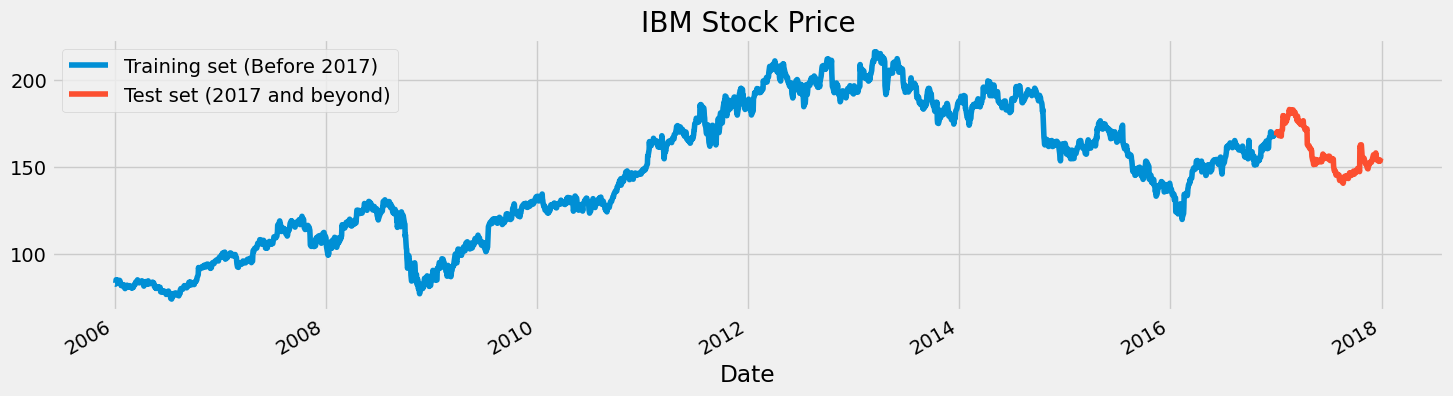

In [7]:
# Splitting the data into training and test sets
training_set = dataset[:'2016'].iloc[:, 1:2].values  # Using the 'High' column
test_set = dataset['2017':].iloc[:, 1:2].values

# Visualizing the Data
dataset["High"][:'2016'].plot(figsize=(16, 4), legend=True)
dataset["High"]['2017':].plot(figsize=(16, 4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM Stock Price')
plt.show()

In [8]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

# Preparing Data structure with 60 timesteps
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping X_train for (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

## Building and Training the LSTM Model

In [9]:
regressor = Sequential()
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.fit(X_train, y_train, epochs=50, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0203
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0091
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0083
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0064
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0061
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0056
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0049
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0039
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0035
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoc

## LSTM Predictions and Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


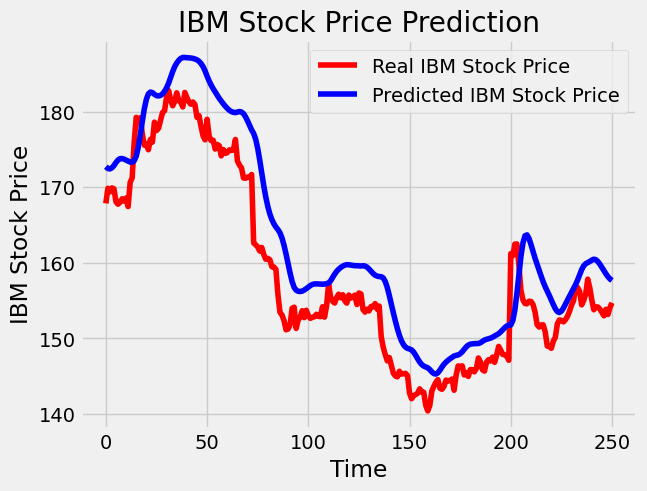

The root mean squared error is 5.549415635550959.


In [10]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

plot_predictions(test_set, predicted_stock_price)
return_rmse(test_set, predicted_stock_price)

## Building and Training the GRU Model

In [11]:
regressorGRU = Sequential()
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

# Using SGD optimizer
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, weight_decay=1e-7, momentum=0.9, nesterov=False), loss='mean_squared_error')
regressorGRU.fit(X_train, y_train, epochs=50, batch_size=150)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1310
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0555
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0243
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0039
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0034
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0033
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0031
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0029
Epoch 16/50
19/

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


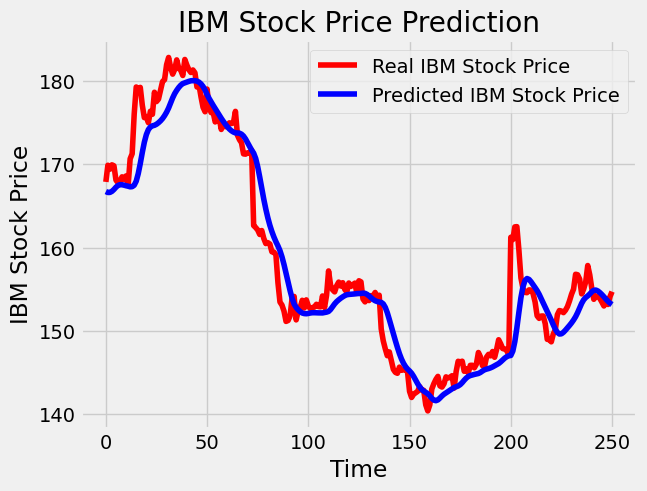

The root mean squared error is 3.2778957750779156.


In [12]:
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

plot_predictions(test_set, GRU_predicted_stock_price)
return_rmse(test_set, GRU_predicted_stock_price)

## Building and Training the SimpleRNN Model

In [13]:
from keras.layers import SimpleRNN

# Building the SimpleRNN model
regressorSimpleRNN = Sequential()
regressorSimpleRNN.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1), activation='tanh'))
regressorSimpleRNN.add(Dropout(0.2))
regressorSimpleRNN.add(SimpleRNN(units=50, return_sequences=True, activation='tanh'))
regressorSimpleRNN.add(Dropout(0.2))
regressorSimpleRNN.add(SimpleRNN(units=50, return_sequences=True, activation='tanh'))
regressorSimpleRNN.add(Dropout(0.2))
regressorSimpleRNN.add(SimpleRNN(units=50, activation='tanh'))
regressorSimpleRNN.add(Dropout(0.2))
regressorSimpleRNN.add(Dense(units=1))

# Compiling and training
regressorSimpleRNN.compile(optimizer='rmsprop', loss='mean_squared_error')
regressorSimpleRNN.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.2867
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1306
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0727
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0405
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0267
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0164
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0117
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0095
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0078
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0060
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0058
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0053
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0046
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0042
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0037
Epoch 16/50
85

In [14]:
# Making predictions with SimpleRNN
SimpleRNN_predicted_stock_price = regressorSimpleRNN.predict(X_test)
SimpleRNN_predicted_stock_price = sc.inverse_transform(SimpleRNN_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


## Comparison of LSTM, GRU, and SimpleRNN

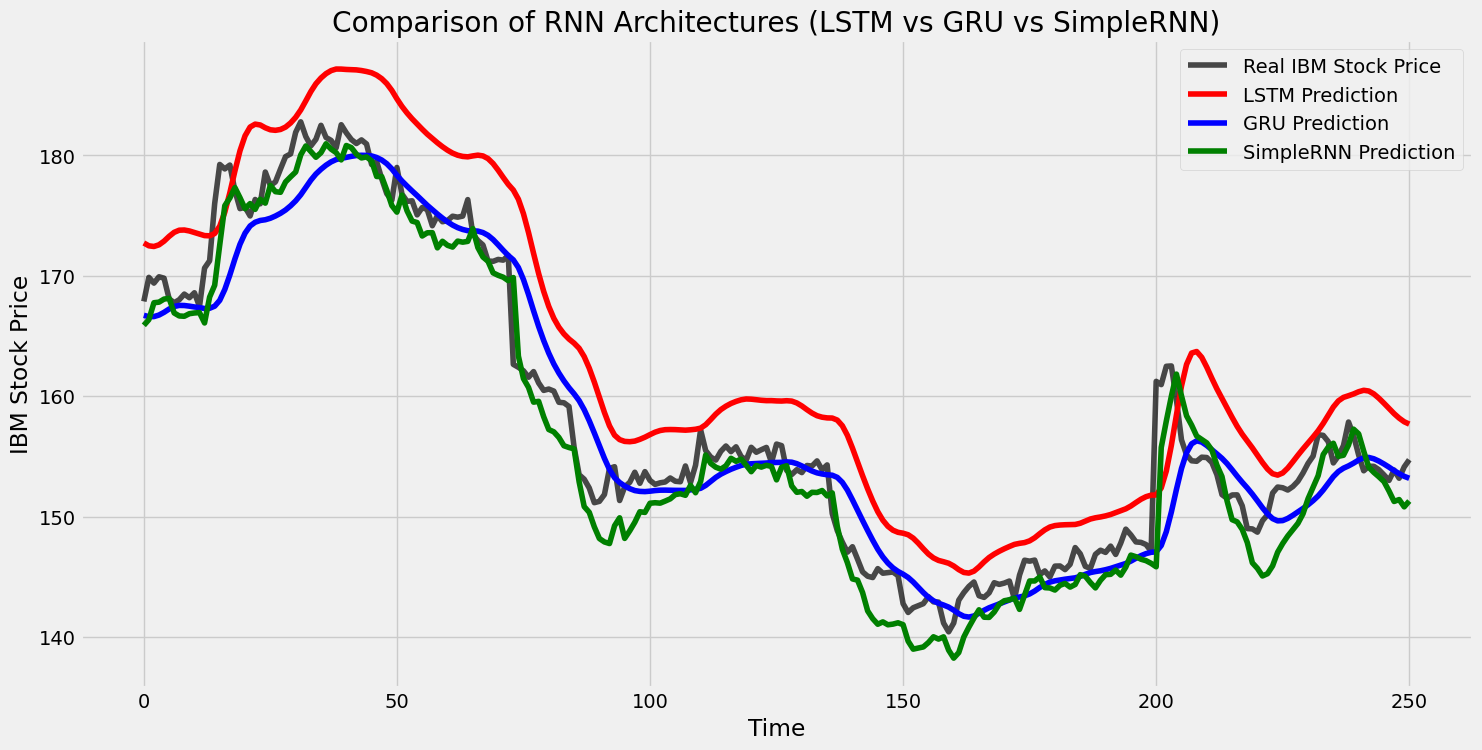

In [15]:
# Visualizing all three results
plt.figure(figsize=(16,8))
plt.plot(test_set, color='black', label='Real IBM Stock Price', alpha=0.7)
plt.plot(predicted_stock_price, color='red', label='LSTM Prediction')
plt.plot(GRU_predicted_stock_price, color='blue', label='GRU Prediction')
plt.plot(SimpleRNN_predicted_stock_price, color='green', label='SimpleRNN Prediction')
plt.title('Comparison of RNN Architectures (LSTM vs GRU vs SimpleRNN)')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend()
plt.show()

In [16]:
# Performance comparison table
rmse_lstm = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
rmse_gru = math.sqrt(mean_squared_error(test_set, GRU_predicted_stock_price))
rmse_simplernn = math.sqrt(mean_squared_error(test_set, SimpleRNN_predicted_stock_price))

perf_data = {
    'Model': ['LSTM', 'GRU', 'SimpleRNN'],
    'RMSE': [rmse_lstm, rmse_gru, rmse_simplernn]
}

perf_df = pd.DataFrame(perf_data)
display(perf_df)

,Model,RMSE
0,LSTM,5.549416
1,GRU,3.277896
2,SimpleRNN,2.642984


## Building and Training the Prophet Model

In [17]:
!pip install prophet

In [18]:
from prophet import Prophet

# Prophet requires a specific format: 'ds' for dates and 'y' for values
df_prophet = dataset.reset_index()[['Date', 'High']]
df_prophet.columns = ['ds', 'y']

# We train only on data before 2017 (matching our previous training sets)
train_prophet = df_prophet[df_prophet['ds'] < '2017-01-01']

# Initialize and fit the model
m = Prophet(daily_seasonality=True)
m.fit(train_prophet)

# Create a dataframe for the test period (2017)
future = df_prophet[df_prophet['ds'] >= '2017-01-01'][['ds']]
forecast = m.predict(future)

# Extract predictions
prophet_predicted_stock_price = forecast['yhat'].values

## Final Comparison: RNNs vs Prophet

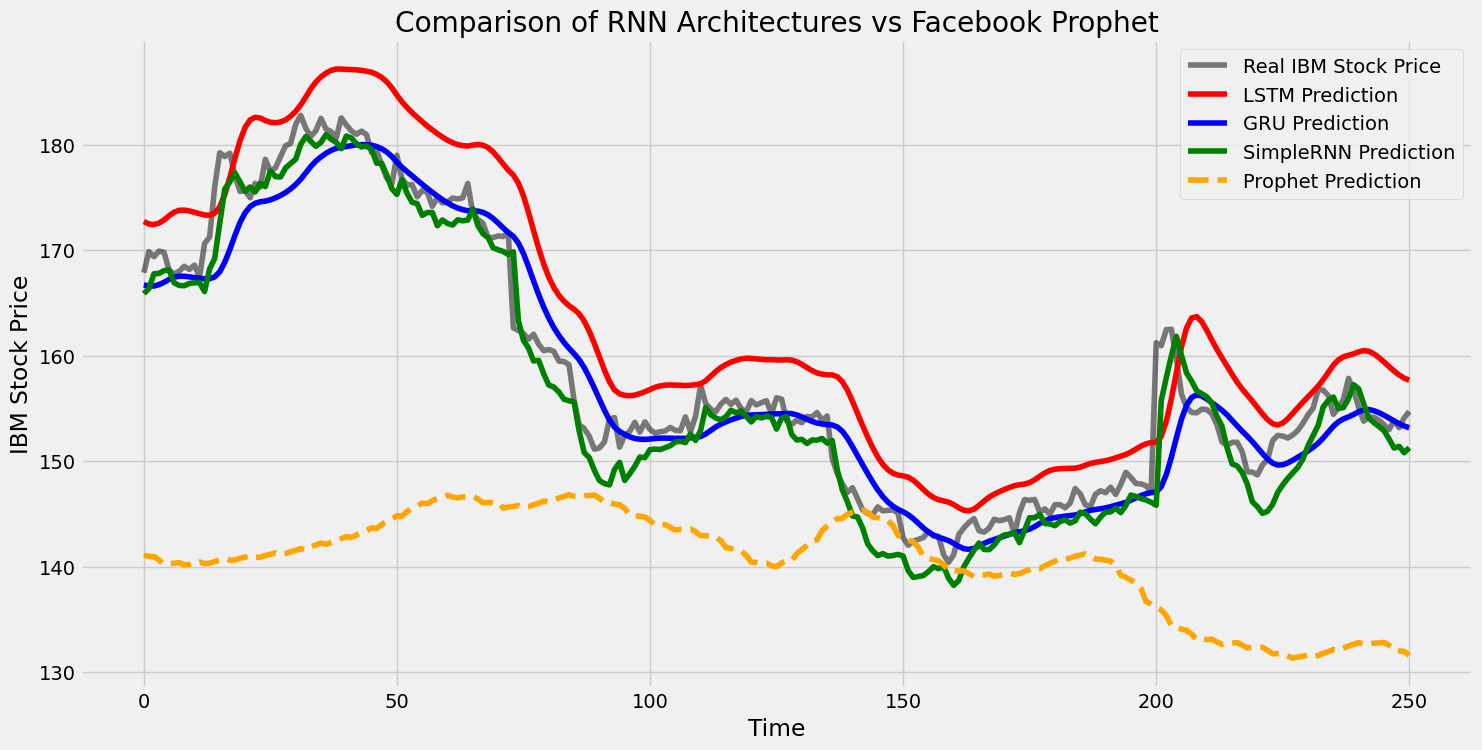

In [19]:
# Visualizing all results including Prophet
plt.figure(figsize=(16,8))
plt.plot(test_set, color='black', label='Real IBM Stock Price', alpha=0.5)
plt.plot(predicted_stock_price, color='red', label='LSTM Prediction')
plt.plot(GRU_predicted_stock_price, color='blue', label='GRU Prediction')
plt.plot(SimpleRNN_predicted_stock_price, color='green', label='SimpleRNN Prediction')
plt.plot(prophet_predicted_stock_price, color='orange', label='Prophet Prediction', linestyle='--')
plt.title('Comparison of RNN Architectures vs Facebook Prophet')
plt.xlabel('Time')
plt.ylabel('IBM Stock Price')
plt.legend()
plt.show()

In [20]:
# Update performance comparison table
rmse_prophet = math.sqrt(mean_squared_error(test_set, prophet_predicted_stock_price))

perf_data = {
    'Model': ['LSTM', 'GRU', 'SimpleRNN', 'Prophet'],
    'RMSE': [rmse_lstm, rmse_gru, rmse_simplernn, rmse_prophet]
}

perf_df = pd.DataFrame(perf_data)
display(perf_df)

,Model,RMSE
0,LSTM,5.549416
1,GRU,3.277896
2,SimpleRNN,2.642984
3,Prophet,21.425811
